$
\def\D{\Omega}
\def\ipar{m}
\def\R{\mathbb{R}}
\def\del{\partial}
\def\vec{\bf}
\def\priorm{\mu_0}
\def\C{\mathcal{C}}
\def\Acal{\mathcal{A}}
\def\postm{\mu_{\rm{post}}}
\def\iparpost{\ipar_\text{post}}
\def\obs{ {\vec d}} 
\def\yobs{\obs^{\text{obs}}}
\def\obsop{\mathcal{B}}
\def\dd{\vec{\bar{d}}}
\def\iFF{\mathcal{F}}
\def\iFFadj{\mathcal{F}^*}
\def\ncov{\Gamma_{\mathrm{noise}}}
$
# Bayesian initial condition inversion in an advection-diffusion problem 

In this example we tackle the problem of quantifying the uncertainty in the solution of an inverse problem governed by a parabolic PDE via the Bayesian inference framework. The underlying PDE is a time-dependent advection-diffusion equation in which we seek to infer an unknown initial condition from spatio-temporal point measurements.

### The Bayesian inverse problem:

Following the Bayesian framework, we utilize 
a Gaussian prior measure $\priorm = \mathcal{N}(\ipar_0,\C_0)$,
with $\C_0=\Acal^{-2}$ where $\Acal$ is an elliptic differential operator as 
described in the PoissonBayesian example, and use an additive
Gaussian noise model. Therefore, the solution of the Bayesian inverse
problem is the posterior measure, $\postm = \mathcal{N}(\iparpost,\C_\text{post})$ with
$\iparpost$ and $\C_\text{post}$.

- The posterior mean $\iparpost$ is characterized as the minimizer of

$$
\begin{aligned}
& \mathcal{J}(\ipar) :=
  \frac{1}{2} \left\| \obsop u(\ipar) -\obs  \right\|^2_{\ncov^{-1}}
  + \frac 12 \left\| \Acal(\ipar - \ipar_0 \right)\|^2_{L^2(\D)},
\end{aligned}
$$

which can also be interpreted as the regularized functional to be
minimized in deterministic inversion. The observation operator $\mathcal{B}$ extracts the values of the forward solution $u$ on a set of
locations $\{{\vec{x}}_1, \ldots, {\vec{x}}_n\} \subset \D$ at
times $\{t_1, \ldots, t_N\} \subset [0, T]$.

- The posterior covariance $\C_{\text{post}}$ is the inverse of the Hessian of $\mathcal{J}(\ipar)$, i.e.,

$$
\C_{\text{post}} = (\iFFadj \ncov^{-1} \iFF + \C_0^{-1})^{-1}.
$$


### The forward problem:

The parameter-to-observable map $\iFF \,\ipar := \obsop\, u(\ipar)$ maps an initial condition $\ipar \in L^2(\D)$ to pointwise spatiotemporal observations of the concentration field $u({\vec x},t)$ through solution of the advection-diffusion equation given by

$$
\begin{split}
u_t - \kappa\Delta u + {\vec v} \cdot \nabla u &= 0     & \quad \text{in } \D\times(0,T),\\
                                 u(\cdot, 0) &= \ipar & \quad \text{in } \D,\\
                \kappa \nabla u\cdot {\vec{n}} &= 0     & \quad \text{on } \partial\D \times (0,T).
\end{split}
$$

Here, $\D \subset \R^d$ ($d \in \{2, 3\}$) is a bounded domain, $\kappa > 0$ is the diffusion coefficient and $T > 0$ is the final
time. The velocity field
$\vec{v}$ is computed by solving the following steady-state
Navier-Stokes equation with the side walls driving the flow:

$$
\begin{aligned}
- \frac{1}{\operatorname{Re}} \Delta {\vec v} + \nabla q + {\vec v} \cdot \nabla {\vec v} &= 0 &\quad&\text{ in }\D,\\
\nabla \cdot {\vec v} &= 0 &&\text{ in }\D,\\
{\vec v} &= {\vec g} &&\text{ on } \partial\D.
\end{aligned}
$$

Here, $q$ is pressure, $\text{Re}$ is the Reynolds number. The Dirichlet boundary data
${\vec g} \in \R^d$ is given by 
${\vec g} = {\vec e}_2$ on the left wall of the domain, 
${\vec g}=-{\vec e}_2$ on the right wall,  and ${\vec g} = {\vec 0}$ everywhere else.

### The adjoint problem:

The adjoint problem is a final value problem, since $p$ is specified at $t = T$ rather than at $t = 0$. Thus, it is solved backwards in time, which amounts to the solution of the advection-diffusion equation

$$
\begin{aligned}
-p_t - \nabla \cdot (p {\vec v}) - \kappa \Delta p  &= -\obsop^* (\obsop u - \obs) & \quad &\text{ in } \D\times (0,T),\\
                                      p(\cdot, T) &= 0             &       &\text{ in } \D,\\ 
({ \vec{v} }p+\kappa\nabla p)\cdot {\vec{n}}            &= 0             &       &\text{ on } \partial\D\times (0,T).
\end{aligned}
$$

Then, the adjoint of the parameter to observable map $\iFF^*$ is defined by setting $\iFF^*\obs = p({\vec x}, 0).$

## 1. Load modules

In [1]:
import dolfin as dl
#import ufl
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import sys
import os
sys.path.append( os.environ.get('HIPPYLIB_BASE_DIR', "../") )
sys.path.insert(1, '/mnt/c/Users/Sonia/Documents/Courant/Research/INLA/hippylib')
from hippylib import *
sys.path.append( os.environ.get('HIPPYLIB_BASE_DIR', "..") + "/applications/ad_diff/" )
from model_ad_diff import SpaceTimePointwiseStateObservation
# modified hippylib code (makes kappa no longer hardcoded)
from model_ad_diff_modified import TimeDependentAD

import logging
logging.getLogger('FFC').setLevel(logging.WARNING)
#logging.getLogger('UFL').setLevel(logging.WARNING)
dl.set_log_active(False)

## 2. Construct the velocity field

In [2]:
# All from original AdvectionDiffusionBayesian tutorial
def v_boundary(x,on_boundary):
    return on_boundary

def q_boundary(x,on_boundary):
    return x[0] < dl.DOLFIN_EPS and x[1] < dl.DOLFIN_EPS
        
def computeVelocityField(mesh):
    Xh = dl.VectorFunctionSpace(mesh,'Lagrange', 2)
    Wh = dl.FunctionSpace(mesh, 'Lagrange', 1)
    mixed_element = dl.MixedElement([Xh.ufl_element(), Wh.ufl_element()])
    XW = dl.FunctionSpace(mesh, mixed_element)

    Re = dl.Constant(1e2)
    
    g = dl.Expression(('0.0','(x[0] < 1e-14) - (x[0] > 1 - 1e-14)'), degree=1)
    bc1 = dl.DirichletBC(XW.sub(0), g, v_boundary)
    bc2 = dl.DirichletBC(XW.sub(1), dl.Constant(0), q_boundary, 'pointwise')
    bcs = [bc1, bc2]
    
    vq = dl.Function(XW)
    (v,q) = dl.split(vq)
    (v_test, q_test) = dl.TestFunctions (XW)
    
    def strain(v):
        return dl.sym(dl.grad(v))
    
    F = ( (2./Re)*dl.inner(strain(v),strain(v_test))+ dl.inner (dl.nabla_grad(v)*v, v_test)
           - (q * dl.div(v_test)) + ( dl.div(v) * q_test) ) * dl.dx
           
    dl.solve(F == 0, vq, bcs, solver_parameters={"newton_solver":
                                         {"relative_tolerance":1e-4, "maximum_iterations":100}})
    
    plt.figure(figsize=(15,5))
    vh = dl.project(v,Xh)
    qh = dl.project(q,Wh)
    nb.plot(nb.coarsen_v(vh), subplot_loc=121,mytitle="Velocity")
    nb.plot(qh, subplot_loc=122,mytitle="Pressure")
    plt.show()
        
    return v

## 3. Set up the mesh and finite element spaces

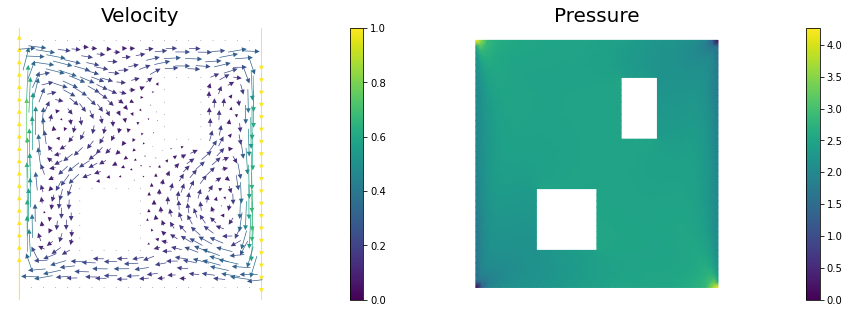

Number of dofs: 2023


In [3]:
mesh = dl.refine( dl.Mesh("ad_20.xml") )
wind_velocity = computeVelocityField(mesh)
Vh = dl.FunctionSpace(mesh, "Lagrange", 1)
print( "Number of dofs: {0}".format( Vh.dim() ) )

## 4. Set up model (prior, true/proposed initial condition)

In [4]:
ic_expr = dl.Expression(
    'std::min(0.5,std::exp(-100*(std::pow(x[0]-0.35,2) +  std::pow(x[1]-0.7,2))))',
    element=Vh.ufl_element())
true_initial_condition = dl.interpolate(ic_expr, Vh).vector()
gamma = 1.
delta = 8.
# initialize prior w/ covariance C = (delta * I + gamma * Laplacian)^{-2}
prior = BiLaplacianPrior(Vh, gamma, delta, robin_bc=True)
# constant mean
prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()
# mean = truth
#prior.mean = true_initial_condition
    
t_init         = 0.
t_final        = 4.
t_1            = 1.
dt             = .1
observation_dt = .2

# Log10 diffusivity
kappa_true = -3
    
simulation_times = np.arange(t_init, t_final+.5*dt, dt)
observation_times = np.arange(t_1, t_final+.5*dt, observation_dt)
    
targets = np.loadtxt('targets.txt')
print ("Number of observation points: {0}".format(targets.shape[0]) )
# initialize observations
misfit = SpaceTimePointwiseStateObservation(Vh, observation_times, targets)

Number of observation points: 80


## 5. Generate the synthetic observations

In [5]:
problem_kappatrue = TimeDependentAD(mesh, [Vh,Vh,Vh], prior, misfit, simulation_times, 10**kappa_true, wind_velocity, True)
#problem_kappatrue = TimeDependentAD(mesh, [Vh,Vh,Vh], prior, misfit, simulation_times, kappa_true, wind_velocity, True)
# relative noise level
#rel_noise = 0.01
rel_noise = 0.1

# initialize vector in the state space
utrue = problem_kappatrue.generate_vector(STATE)
x = [utrue, true_initial_condition, None]
# solve forward problem
problem_kappatrue.solveFwd(x[STATE], x)
# observe solution and add error
misfit.observe(x, misfit.d)
MAX = misfit.d.norm("linf", "linf")
noise_std_dev = rel_noise * MAX
parRandom.normal_perturb(noise_std_dev,misfit.d)

misfit.noise_variance = noise_std_dev*noise_std_dev

# plot solution
#nb.show_solution(Vh, true_initial_condition, utrue, "Solution")
#plt.savefig("forward_solution.pdf",pad_inches=1)

(yy, H xx) - (xx, H yy) =  5.792653942400288e-13


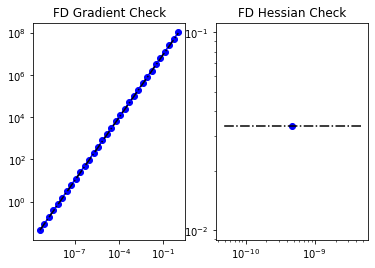

In [6]:
m0 = true_initial_condition.copy()
_ = modelVerify(problem_kappatrue, m0, is_quadratic=True)

In [ ]:
# # compare spectra of H(k0), H(k1), and their difference H(k0)-H(k1)

# # note: this *is* prior-preconditioned
# class HessianDifference:
#     """
#     This is a bare-bones class for the operator H(model0)-H(model1)
#     """
#     def __init__(self, model0, model1, misfit_only=False):
#         """
#         Construct the Hessian difference operator
#         """z
#         self.H0 = ReducedHessian(model0, misfit_only)
#         self.H1 = ReducedHessian(model1, misfit_only)
#         self.yhelp = model1.generate_vector(PARAMETER)
#     def mult(self, x, y):
#         """
#         Writes (H(model0)-H(model1))*x to y
#         """
#         self.H0.mult(x,y)
#         self.H1.mult(x,self.yhelp)
#         y.axpy(-1.0,self.yhelp)
        
# kappa0 = 0.001
# kappa1 = 0.0011
        
# model0 = TimeDependentAD(mesh, [Vh,Vh,Vh], prior, misfit, simulation_times, kappa0, wind_velocity, True)
# model1 = TimeDependentAD(mesh, [Vh,Vh,Vh], prior, misfit, simulation_times, kappa1, wind_velocity, True)

# H0 = ReducedHessian(model0, misfit_only=True)
# H1 = ReducedHessian(model1, misfit_only=True)
# H_diff = HessianDifference(model0, model1, misfit_only=True)
# # using the same Omega (random matrix) for all of them -- is this an issue? 
# k = 120
# p = 40
# Omega = MultiVector(x[PARAMETER], k+p)
# parRandom.normal(1., Omega)
# lmbda0, V0 = singlePassG(H0, prior.R, prior.Rsolver, Omega, k)
# lmbda1, V1 = singlePassG(H1, prior.R, prior.Rsolver, Omega, k)
# lmbda_diff, V_diff = singlePassG(H_diff, prior.R, prior.Rsolver, Omega, k)

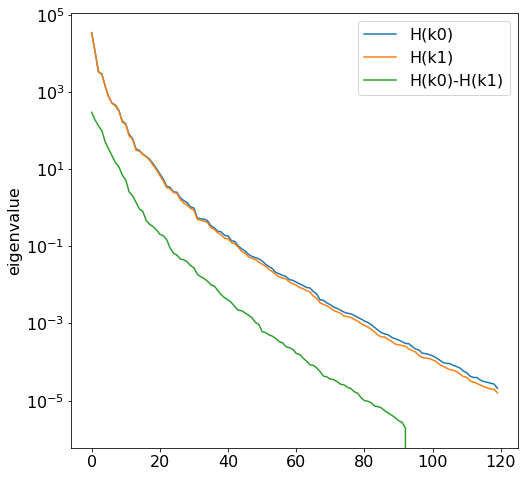

In [23]:
# plt.figure(figsize=(8,8))
# plt.rcParams.update({'font.size': 16})
# plt.semilogy(lmbda0,label='H(k0)')
# plt.semilogy(lmbda1,label='H(k1)')
# plt.semilogy(lmbda_diff,label='H(k0)-H(k1)')
# plt.ylabel('eigenvalue')
# plt.legend()

In [10]:
# initialize problem object
def ComputePosterior(mesh, Vh, prior, misfit, simulation_times, kappa, wind_velocity):
    problem = TimeDependentAD(mesh, [Vh,Vh,Vh], prior, misfit, simulation_times, kappa, wind_velocity, True)
    
    ## Compute the gradient
    [u,m,p] = problem.generate_vector()
    # forward solve
    problem.solveFwd(u, [u,m,p])
    # adjoint solve
    problem.solveAdj(p, [u,m,p])
    # initialize a vector in the parameter space
    mg = problem.generate_vector(PARAMETER)
    # evaluate gradient and store in mg
    grad_norm = problem.evalGradientParameter([u,m,p], mg)
    
    ## Compute posterior precision
    # matrix free application of posterior precision/covariance
    H = ReducedHessian(problem, misfit_only=True) 
    
    # finds eigenvalues/vectors of H*x = lambda*R*x
    k = 120
    p = 40
    Omega = MultiVector(x[PARAMETER], k+p)
    parRandom.normal(1., Omega)
    lmbda, V = singlePassG(H, prior.R, prior.Rsolver, Omega, k)

    posterior = GaussianLRPosterior( prior, lmbda, V )
    
    ## Compute posterior mean
    H.misfit_only = False
        
    solver = CGSolverSteihaug()
    solver.set_operator(H)
    solver.set_preconditioner( posterior.Hlr )
    solver.parameters["print_level"] = 1
    solver.parameters["rel_tolerance"] = 1e-6
    solver.solve(m, -mg)
    problem.solveFwd(u, [u,m,p])
 
    #total_cost, reg_cost, misfit_cost = problem.cost([u,m,p])
    #print( "Total cost {0:5g}; Reg Cost {1:5g}; Misfit {2:5g}".format(total_cost, reg_cost, misfit_cost) )
    posterior.mean = m
    #plt.figure(figsize=(7.5,5))
    #nb.plot(dl.Function(Vh, m), mytitle="Initial Condition")
    #plt.show()
    #nb.show_solution(Vh, m, u, "Solution")
    
    return posterior,mg

In [11]:
# prior precision of kappa -- normal centered at -2, stdev = 3 (log values)
q_kappa = 1/3
# prior mean of kappa
mu_kappa = -2

In [12]:
# -log pi(kappa | u_d) (- log posterior marginal distribution of kappa)
def neglogpi(kappa):
    # compute new posterior
    posterior,mg = ComputePosterior(mesh, Vh, prior, misfit, simulation_times, 10**kappa, wind_velocity)
    det_ratio = 0.0
    # -log(|Q_u_0|/|Q_u_0^\ast|)
    for ll in posterior.d:
        det_ratio += np.log(1+ll)
    kappa_prior = 0.5*(q_kappa**2)*(kappa-mu_kappa)**2
    # u_0^\ast^T Q_u_0^\ast u_0^\ast
    #uQu = - 0.5*posterior.Hlr.inner(posterior.mean,posterior.mean) # does unnecessary work + introduces error
    uQu = 0.5*mg.inner(posterior.mean)
    return det_ratio,kappa_prior,uQu

# plot -log pi for a range of kappas
kap_range = np.log10(np.linspace(0.0005,0.002,11))
logpi = np.array([0.0]*len(kap_range))
det_ratios = np.array([0.0]*len(kap_range))
kappa_priors = np.array([0.0]*len(kap_range))
uQus = np.array([0.0]*len(kap_range))

for idx in range(len(kap_range)):
    print(f"Kappa iteration: {idx}")
    det_ratios[idx],kappa_priors[idx],uQus[idx] = neglogpi(kap_range[idx])
    logpi[idx] = det_ratios[idx] + kappa_priors[idx] + uQus[idx]

Kappa iteration: 0
 Iterartion :  0  (B r, r) =  12161.606771977544
 Iteration :  1  (B r, r) =  0.001971863584565228
 Iteration :  2  (B r, r) =  1.7987976902442714e-08
 Iteration :  3  (B r, r) =  5.6507244398914636e-14
Relative/Absolute residual less than tol
Converged in  3  iterations with final norm  2.3771252469929857e-07
Kappa iteration: 1
 Iterartion :  0  (B r, r) =  12217.986166427376
 Iteration :  1  (B r, r) =  0.00032571192456617916
 Iteration :  2  (B r, r) =  2.4001651047105395e-10
Relative/Absolute residual less than tol
Converged in  2  iterations with final norm  1.549246624882733e-05
Kappa iteration: 2
 Iterartion :  0  (B r, r) =  12238.867364318186
 Iteration :  1  (B r, r) =  1.3949889242816565e-05
 Iteration :  2  (B r, r) =  3.1319302980285872e-12
Relative/Absolute residual less than tol
Converged in  2  iterations with final norm  1.7697260516895226e-06
Kappa iteration: 3
 Iterartion :  0  (B r, r) =  12241.138655695113
 Iteration :  1  (B r, r) =  1.035397420

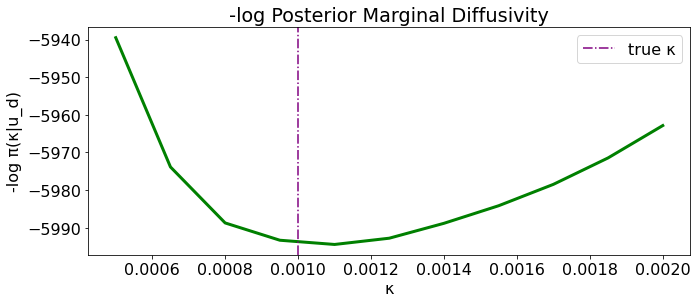

In [13]:
plt.figure(figsize=(10,4.5))
plt.rcParams.update({'font.size': 16})
plt.plot(10**kap_range,logpi,linewidth=3,color='green')
#plt.plot(10**kap_range,logpi-np.min(logpi),linewidth=3,color='green')
plt.axvline(x=0.001, color='purple', linestyle="-.", label="true κ")
#plt.ticklabel_format(axis='both', style='sci', scilimits=(0,0))
plt.title(f'-log Posterior Marginal Diffusivity')
plt.ylabel("-log π(κ|u_d)")
plt.xlabel("κ")
#plt.xticks([0.00090, 0.00095, 0.00100, 0.00105, 0.00110]) 
plt.tight_layout()
plt.legend()
#plt.savefig("logpi.pdf")

In [14]:
kappa10 = np.power(10,kap_range)
dkappa = kappa10[1]-kappa10[0]
pi_tilde = np.exp(-(logpi-np.min(logpi)))
Z = 0.0
for idx in range(len(kappa10)-1):
    Z += dkappa*0.5*(pi_tilde[idx+1]+pi_tilde[idx])
Z

0.0002282609392428564

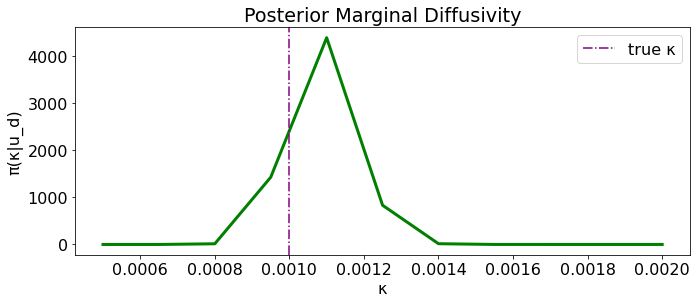

In [15]:
plt.figure(figsize=(10,4.5))
plt.rcParams.update({'font.size': 16})
plt.plot(10**kap_range,pi_tilde/Z,linewidth=3,color='green')
plt.axvline(x=0.001, color='purple', linestyle="-.", label="true κ")
#plt.ticklabel_format(axis='both', style='sci', scilimits=(0,0))
plt.title(f'Posterior Marginal Diffusivity')
plt.ylabel("π(κ|u_d)")
plt.xlabel("κ")
#plt.xticks([0.00090, 0.00095, 0.00100, 0.00105, 0.00110]) 
plt.tight_layout()
plt.legend()
#plt.savefig("pi_tilde.pdf")

In [16]:
det_ratios

array([140.60861737, 134.94197942, 130.59634988, 127.156145  ,
       124.09770153, 121.41598746, 118.98525816, 116.75839843,
       114.69285405, 112.76424356, 110.95035355])

In [17]:
kappa_priors

array([0.09403772, 0.07828748, 0.06684509, 0.05805828, 0.05105155,
       0.04530953, 0.04050541, 0.03642015, 0.03290049, 0.0298354 ,
       0.02714217])

In [18]:
uQus

array([-6080.20970094, -6108.87929746, -6119.40352492, -6120.55065048,
       -6118.60841959, -6114.2580289 , -6107.86162505, -6100.95949476,
       -6093.21152199, -6084.25034587, -6073.8332838 ])

Text(0.5, 0, 'kappa')

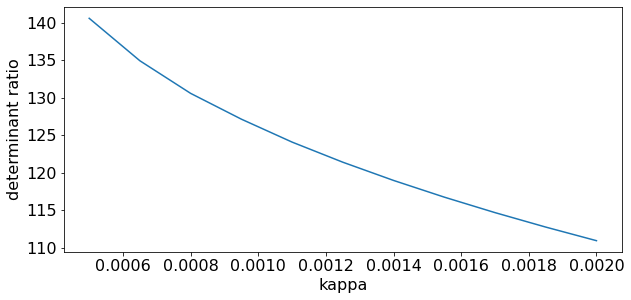

In [19]:
plt.figure(figsize=(10,4.5))
plt.plot(10**kap_range,det_ratios)
plt.ylabel("determinant ratio")
plt.xlabel("kappa")

Text(0.5, 0, 'kappa')

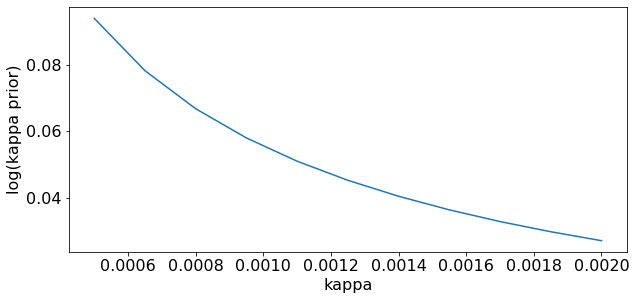

In [20]:
plt.figure(figsize=(10,4.5))
plt.plot(10**kap_range,kappa_priors)
plt.ylabel("log(kappa prior)")
plt.xlabel("kappa")

Text(0.5, 0, 'kappa')

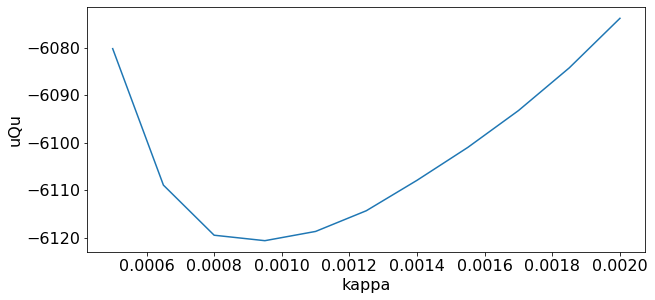

In [21]:
plt.figure(figsize=(10,4.5))
plt.plot(10**kap_range,uQus)
plt.ylabel("uQu")
plt.xlabel("kappa")